# 04 · Resultados y Análisis Comparativo

Lee los CSVs generados por `03_evaluacion.ipynb` y produce:
- Tabla principal modelo × variante
- Curvas de aprendizaje
- Análisis mono-fuente vs multi-fuente
- Análisis por capa retinal
- Test estadístico Wilcoxon
- Tabla de trade-offs complejidad/rendimiento

In [7]:
import os
from pathlib import Path

def _detect_env():
    if os.environ.get('KAGGLE_KERNEL_RUN_TYPE'): return 'kaggle'
    try:
        import google.colab; return 'colab'
    except ImportError: pass
    try: get_ipython(); return 'notebook'
    except NameError: return 'script'

ENV = _detect_env()
if ENV == 'kaggle': ROOT_DIR = Path('/kaggle/working')
elif ENV == 'colab':
    from google.colab import drive; drive.mount('/content/drive')
    ROOT_DIR = Path('/content/drive/MyDrive/oct-retina-segmentation')
else:
    _here = Path(globals().get('__file__', './')).resolve()
    ROOT_DIR = _here.parents[1] if _here.suffix == '.py' else _here.parent

EVAL_DIR  = ROOT_DIR / 'evaluation'
LOGS_DIR  = ROOT_DIR / 'results'/'logs'
FIGS_DIR  = ROOT_DIR / 'figures'
FIGS_DIR.mkdir(parents=True, exist_ok=True)
print(f'[ENV] {ENV}  |  FIGS_DIR={FIGS_DIR}')

[ENV] notebook  |  FIGS_DIR=C:\Users\User\oct-retina-segmentation\OCT\VC2\TP_vision_por_computadora_2\figures


In [3]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [4]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import wilcoxon

sns.set_theme(style='whitegrid', font_scale=1.1)
COLORS = {'unet':'#4e79a7','unetpp':'#f28e2b',
          'resnet_unet':'#e15759','segformer':'#76b7b2'}
MODEL_LABELS = {'unet':'U-Net','unetpp':'U-Net++',
                'resnet_unet':'ResNet34-UNet','segformer':'SegFormer-B2'}

# Cargar datos
df = pd.read_csv(EVAL_DIR / 'metricas_por_clase.csv')
print(f'[OK] {len(df)} filas cargadas.')
print(f'     Modelos  : {df["model"].unique().tolist()}')
print(f'     Variantes: {df["variant"].unique().tolist()}')

[OK] 9 filas cargadas.
     Modelos  : ['unetpp']
     Variantes: ['v1_kaggle_8c']


---
## 1 · Tabla principal — Dice/IoU/F1/Hausdorff por modelo × variante

In [5]:
tabla = df.groupby(['model','variant']).agg(
    Dice=('dice','mean'), IoU=('iou','mean'),
    F1=('f1','mean'), Hausdorff=('hd','mean'),
    Infer_ms=('infer_ms','first'), GPU_MB=('gpu_mb','first'),
    Params_M=('n_params_M','first')
).round(4).reset_index()
tabla['model'] = tabla['model'].map(MODEL_LABELS).fillna(tabla['model'])

print('=== TABLA PRINCIPAL ===')
print(tabla.to_string(index=False))
tabla.to_csv(FIGS_DIR / 'tabla_principal.csv', index=False)
print(f'\n[OK] Guardada: tabla_principal.csv')

=== TABLA PRINCIPAL ===
  model      variant   Dice    IoU     F1  Hausdorff  Infer_ms  GPU_MB  Params_M
U-Net++ v1_kaggle_8c 0.8439 0.8043 0.8439     3.3622   1345.59     0.0     36.63

[OK] Guardada: tabla_principal.csv


---
## 2 · Curvas de aprendizaje

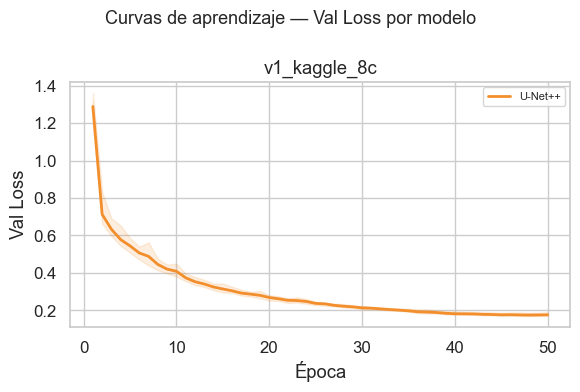

[OK] curvas_aprendizaje.png


In [8]:
# Leer CSVs de entrenamiento generados por cada notebook 02x
dfs_train = []
for csv_path in LOGS_DIR.glob('*.csv'):
    if 'resultados' in csv_path.name: continue
    try:
        _df = pd.read_csv(csv_path)
        if 'epoch' in _df.columns and 'val_loss' in _df.columns:
            dfs_train.append(_df)
    except: pass

if not dfs_train:
    print('[SKIP] No se encontraron CSVs de entrenamiento.')
else:
    df_train = pd.concat(dfs_train, ignore_index=True)
    variants_plot = df_train['variant'].unique()[:3]  # primeras 3

    fig, axes = plt.subplots(1, len(variants_plot), figsize=(6*len(variants_plot), 4))
    if len(variants_plot) == 1: axes = [axes]

    for ax, var in zip(axes, variants_plot):
        for model_name, color in COLORS.items():
            sub = df_train[(df_train['model']==model_name) &
                           (df_train['variant']==var)]
            if sub.empty: continue
            # Promedio por epoca sobre todos los folds
            avg = sub.groupby('epoch')[['train_loss','val_loss']].mean()
            ax.plot(avg.index, avg['val_loss'], color=color,
                    label=MODEL_LABELS.get(model_name, model_name), linewidth=2)
            ax.fill_between(
                avg.index,
                sub.groupby('epoch')['val_loss'].min(),
                sub.groupby('epoch')['val_loss'].max(),
                color=color, alpha=0.15
            )
        ax.set_title(var); ax.set_xlabel('Época'); ax.set_ylabel('Val Loss')
        ax.legend(fontsize=8)

    plt.suptitle('Curvas de aprendizaje — Val Loss por modelo', fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGS_DIR / 'curvas_aprendizaje.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('[OK] curvas_aprendizaje.png')

---
## 3 · Mono-fuente vs Multi-fuente

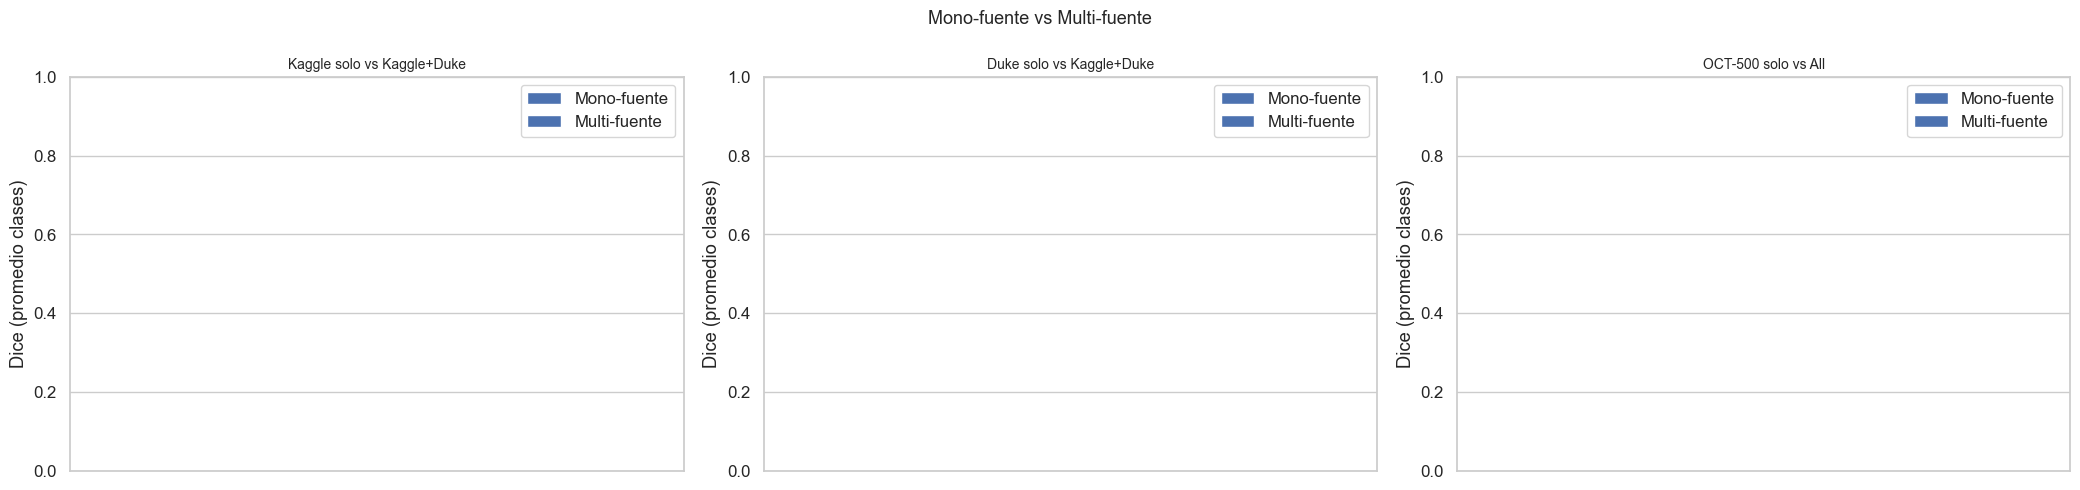

[OK] mono_vs_multi.png


In [9]:
# Comparar V1/V2 (mono) vs V3 (multi) para 8 clases
# Comparar V4 (mono) vs V5 (multi) para 6 clases
comparisons = [
    ('v1_kaggle_8c',      'v3_kaggle_duke_8c', 'Kaggle solo vs Kaggle+Duke'),
    ('v2_duke_8c',        'v3_kaggle_duke_8c', 'Duke solo vs Kaggle+Duke'),
    ('v4_oct500_6c',      'v5_all_6c',         'OCT-500 solo vs All'),
]

fig, axes = plt.subplots(1, len(comparisons), figsize=(7*len(comparisons), 5))
if len(comparisons) == 1: axes = [axes]

for ax, (v_mono, v_multi, title) in zip(axes, comparisons):
    df_mono  = df[df['variant']==v_mono].groupby('model')['dice'].mean()
    df_multi = df[df['variant']==v_multi].groupby('model')['dice'].mean()
    models   = sorted(set(df_mono.index) & set(df_multi.index))
    x = np.arange(len(models))
    w = 0.35
    bars1 = ax.bar(x-w/2, [df_mono.get(m,0) for m in models],  w,
                   label='Mono-fuente', color='#4e79a7', alpha=0.85)
    bars2 = ax.bar(x+w/2, [df_multi.get(m,0) for m in models], w,
                   label='Multi-fuente', color='#e15759', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS.get(m,m) for m in models], rotation=15, ha='right')
    ax.set_ylabel('Dice (promedio clases)')
    ax.set_title(title, fontsize=10)
    ax.legend()
    ax.set_ylim(0, 1)
    # Diferencia porcentual encima de cada par
    for i, m in enumerate(models):
        d1, d2 = df_mono.get(m,0), df_multi.get(m,0)
        if d1 > 0:
            diff = (d2-d1)/d1*100
            ax.text(i, max(d1,d2)+0.02, f'{diff:+.1f}%', ha='center', fontsize=8)

plt.suptitle('Mono-fuente vs Multi-fuente', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'mono_vs_multi.png', dpi=150, bbox_inches='tight')
plt.show()
print('[OK] mono_vs_multi.png')

---
## 4 · Análisis por capa retinal

In [10]:
# Heatmap: modelo × capa, valor = Dice
# Solo para variante V3 (la mas completa de 8 clases)
df_v3 = df[df['variant']=='v3_kaggle_duke_8c']

if not df_v3.empty:
    pivot = df_v3.pivot_table(index='class_name', columns='model',
                              values='dice', aggfunc='mean')
    pivot.columns = [MODEL_LABELS.get(c,c) for c in pivot.columns]

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
                vmin=0, vmax=1, ax=ax, linewidths=0.5)
    ax.set_title('Dice por capa retinal × modelo (V3: Kaggle+Duke)', fontsize=12)
    ax.set_xlabel('Modelo'); ax.set_ylabel('Capa')
    plt.tight_layout()
    plt.savefig(FIGS_DIR / 'heatmap_capas.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('[OK] heatmap_capas.png')

    # Identificar las capas mas dificiles
    mean_by_layer = df_v3.groupby('class_name')['dice'].mean().sort_values()
    print('\nCapas ordenadas de mas dificil a mas facil (Dice):')
    for layer, dice in mean_by_layer.items():
        print(f'  {layer:25s}: {dice:.4f}')
else:
    print('[SKIP] No hay datos para V3.')

[SKIP] No hay datos para V3.


---
## 5 · Test estadístico Wilcoxon

In [11]:
# Comparar cada par de modelos con test de Wilcoxon sobre los Dice por clase
# H0: no hay diferencia significativa entre los dos modelos
# p < 0.05 → diferencia significativa

models_list = df['model'].unique()
wilcoxon_results = []

for var in df['variant'].unique():
    df_var = df[df['variant']==var]
    for i, m1 in enumerate(models_list):
        for m2 in models_list[i+1:]:
            dice1 = df_var[df_var['model']==m1]['dice'].values
            dice2 = df_var[df_var['model']==m2]['dice'].values
            if len(dice1) < 2 or len(dice1) != len(dice2): continue
            try:
                stat, p = wilcoxon(dice1, dice2)
                wilcoxon_results.append({
                    'variant': var,
                    'model_1': MODEL_LABELS.get(m1, m1),
                    'model_2': MODEL_LABELS.get(m2, m2),
                    'statistic': round(stat, 4),
                    'p_value': round(p, 6),
                    'significativo': '✓' if p < 0.05 else '✗',
                    'dice_m1_mean': round(dice1.mean(), 4),
                    'dice_m2_mean': round(dice2.mean(), 4),
                })
            except Exception: pass

if wilcoxon_results:
    df_w = pd.DataFrame(wilcoxon_results)
    print('=== TEST WILCOXON (p < 0.05 = diferencia significativa) ===')
    print(df_w.to_string(index=False))
    df_w.to_csv(FIGS_DIR / 'wilcoxon_tests.csv', index=False)
    sig = df_w[df_w['p_value'] < 0.05]
    print(f'\n  Pares significativos: {len(sig)} de {len(df_w)}')
else:
    print('[SKIP] No hay suficientes datos para Wilcoxon.')

[SKIP] No hay suficientes datos para Wilcoxon.


---
## 6 · Tabla de trade-offs complejidad vs rendimiento

=== TRADE-OFFS: Complejidad vs Rendimiento ===
  model  Dice_mean  IoU_mean  Infer_ms  GPU_MB  Params_M
U-Net++     0.8439    0.8043   1345.59     0.0     36.63


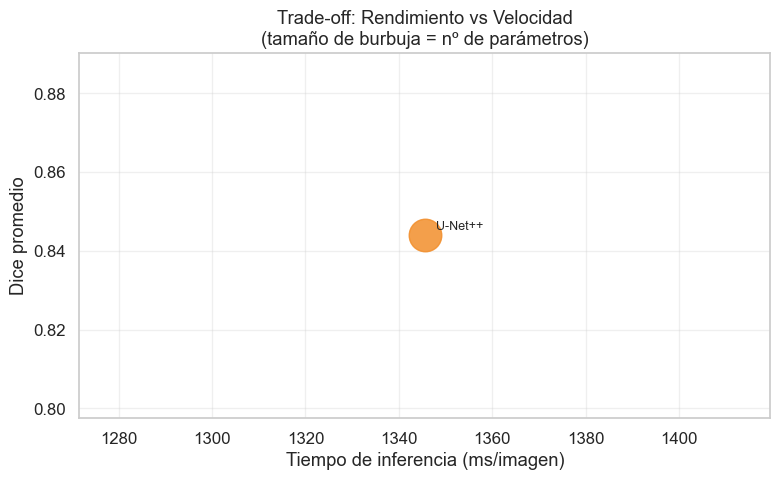

[OK] tradeoff_scatter.png

  → Siguiente: 05_visualizacion.ipynb


In [12]:
tradeoffs = df.groupby('model').agg(
    Dice_mean=('dice','mean'),
    IoU_mean=('iou','mean'),
    Infer_ms=('infer_ms','mean'),
    GPU_MB=('gpu_mb','mean'),
    Params_M=('n_params_M','mean'),
).round(4).reset_index()
tradeoffs['model'] = tradeoffs['model'].map(MODEL_LABELS).fillna(tradeoffs['model'])
tradeoffs = tradeoffs.sort_values('Dice_mean', ascending=False)

print('=== TRADE-OFFS: Complejidad vs Rendimiento ===')
print(tradeoffs.to_string(index=False))
tradeoffs.to_csv(FIGS_DIR / 'tradeoffs.csv', index=False)

# Grafico scatter: Dice vs tiempo de inferencia
fig, ax = plt.subplots(figsize=(8, 5))
for _, row in tradeoffs.iterrows():
    m = row['model']
    key = {v:k for k,v in MODEL_LABELS.items()}.get(m, m)
    color = COLORS.get(key, 'gray')
    ax.scatter(row['Infer_ms'], row['Dice_mean'],
               s=row['Params_M']*15, color=color, alpha=0.85, zorder=3)
    ax.annotate(m, (row['Infer_ms'], row['Dice_mean']),
                textcoords='offset points', xytext=(8,4), fontsize=9)

ax.set_xlabel('Tiempo de inferencia (ms/imagen)')
ax.set_ylabel('Dice promedio')
ax.set_title('Trade-off: Rendimiento vs Velocidad\n(tamaño de burbuja = nº de parámetros)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'tradeoff_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('[OK] tradeoff_scatter.png')
print('\n  → Siguiente: 05_visualizacion.ipynb')